## Generative Adversarial Network (GAN) Example
Autoencoders, GANs, and Generative Algorithms (Module 11)

### Overview

GANs frame generative modeling as a two-player minimax game:
- Generator $G_\theta$: maps latent noise $z \sim p(z)$ to synthetic samples $\tilde{x} = G(z)$
- Discriminator $D_\phi$: outputs $P(x \text{ is real}) \in (0, 1)$

Minimax objective:
$$\min_\theta \max_\phi \; \mathbb{E}[\log D(x)] + \mathbb{E}[\log(1 - D(G(z)))]$$

Optimal discriminator:
$$D^*(x) = \frac{p_{\text{data}}(x)}{p_{\text{data}}(x) + p_g(x)}$$

At **Nash equilibrium: $p_g = p_{\text{data}}$ and $D^*(x) = 0.5$ for all x, indicating maximal uncertainty.

Non-saturating generator loss — avoids vanishing gradients early in training:
- Maximizes $\mathbb{E}[\log D(G(z))]$

Task:
- Target: 2D Gaussian, mean = [3, 3], std = 1 per dimension
- Latent prior: $p(z) = \mathcal{N}(0, I_{10})$

Convergence diagnostics: at equilibrium
- `loss_D` → 1.386, `loss_G` → 0.693
- `D(real)` → 0.5, `D(fake)` → 0.5
- `fake_mean` → [3, 3], `fake_std` → [1, 1]

### Imports & Hyperparameters

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# Hyperparameters and settings
NOISE_DIM  = 10      # dimension of latent space z
DATA_DIM   = 2       # dimension of data x
HIDDEN_DIM = 16      # hidden units in each MLP
BATCH_SIZE = 128
LR         = 1e-3
BETAS      = (0.5, 0.999)   # Adam betas — 0.5 recommended for GANs
EPOCHS     = 2000
LOG_EVERY  = 200

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

Using device: cpu


### Architecture

#### Generator $G_\theta$
Maps latent noise $z \sim \mathcal{N}(0, I)$ to synthetic samples via a small MLP.

#### Discriminator $D_\phi$
Binary classifier (Sigmoid output) trained to distinguish real (label=1) from fake (label=0) samples.

In [2]:
class Generator(nn.Module):
    """
    G_theta: R^noise_dim -> R^data_dim

    Maps latent noise z ~ N(0, I) to synthetic samples intended to
    match the real data distribution p_data.
    """
    def __init__(self, noise_dim=NOISE_DIM, data_dim=DATA_DIM, hidden=HIDDEN_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(noise_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, data_dim),
        )

    def forward(self, z):
        return self.net(z)


class Discriminator(nn.Module):
    """
    D_phi: R^data_dim -> (0, 1)

    Binary classifier trained to distinguish real samples (label=1) from
    generated/fake samples (label=0). Sigmoid output gives P(x is real).
    """
    def __init__(self, data_dim=DATA_DIM, hidden=HIDDEN_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(data_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.net(x)

### Data Helpers & Model Setup

The real data is a 2D Gaussian $\mathcal{N}([3,3], I_2)$ — the target distribution.

In [ ]:
def sample_real(n=BATCH_SIZE):
    """Real data: 2D Gaussian, mean=[3,3], std=1."""
    return torch.randn(n, DATA_DIM, device=DEVICE) + 3.0

def sample_noise(n=BATCH_SIZE):
    """Latent prior p(z) = N(0, I)."""
    return torch.randn(n, NOISE_DIM, device=DEVICE)


# Instantiate models
G = Generator().to(DEVICE)
D = Discriminator().to(DEVICE)

# Separate optimizers for G and D — standard GAN practice that allows independent
# learning rate tuning per network
opt_G = optim.Adam(G.parameters(), lr=LR, betas=BETAS)
opt_D = optim.Adam(D.parameters(), lr=LR, betas=BETAS)

criterion = nn.BCELoss()   # Binary cross-entropy for the minimax objective

print("Generator:")
print(G)
print("\nDiscriminator:")
print(D)

Generator:
Generator(
  (net): Sequential(
    (0): Linear(in_features=10, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=2, bias=True)
  )
)

Discriminator:
Discriminator(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=1, bias=True)
    (3): Sigmoid()
  )
)


### Training Loop

Each epoch alternates two steps:

1. **Train Discriminator** — maximize $\mathbb{E}[\log D(x_{\text{real}})] + \mathbb{E}[\log(1 - D(G(z)))]$
2. **Train Generator** — non-saturating loss: maximize $\mathbb{E}[\log D(G(z))]$  
   (labels fakes as "real" so BCE computes $-\mathbb{E}[\log D(G(z))]$)

In [4]:
history = {"loss_D": [], "loss_G": [], "D_real": [], "D_fake": [],
           "fake_mean_x": [], "fake_mean_y": [], "fake_std_x": [], "fake_std_y": []}

print(f"{'Epoch':>6}  {'loss_D':>7}  {'loss_G':>7}  {'D(real)':>7}  {'D(fake)':>7}"
      f"  {'fake_mean':>14}  {'fake_std':>14}")
print("-" * 80)

for epoch in range(1, EPOCHS + 1):

    # Step 1: Train Discriminator
    real = sample_real()
    z    = sample_noise()
    fake = G(z).detach()          # detach so G is not updated in D's backward pass

    D_real = D(real)
    D_fake = D(fake)

    # loss_D = -E[log D(x_real)] - E[log(1 - D(G(z)))]
    loss_D = criterion(D_real, torch.ones_like(D_real)) + \
             criterion(D_fake, torch.zeros_like(D_fake))

    opt_D.zero_grad()
    loss_D.backward()
    opt_D.step()

    # Step 2: Train Generator (non-saturating loss)
    z    = sample_noise()
    fake = G(z)
    D_fake_for_G = D(fake)

    # Non-saturating: label fakes as "real" (ones) => loss = -E[log D(G(z))]
    # Provides stronger gradients than the saturating form early in training.
    loss_G = criterion(D_fake_for_G, torch.ones_like(D_fake_for_G))

    opt_G.zero_grad()
    loss_G.backward()
    opt_G.step()

    # Logging
    if epoch % LOG_EVERY == 0 or epoch == 1:
        with torch.no_grad():
            real_eval = sample_real(2048)
            fake_eval = G(sample_noise(2048))

            fm = fake_eval.mean(dim=0)
            fs = fake_eval.std(dim=0, unbiased=False)
            Dr = D(real_eval).mean().item()
            Df = D(fake_eval).mean().item()

        history["loss_D"].append(loss_D.item())
        history["loss_G"].append(loss_G.item())
        history["D_real"].append(Dr)
        history["D_fake"].append(Df)
        history["fake_mean_x"].append(fm[0].item())
        history["fake_mean_y"].append(fm[1].item())
        history["fake_std_x"].append(fs[0].item())
        history["fake_std_y"].append(fs[1].item())

        print(f"{epoch:>6}  {loss_D.item():>7.3f}  {loss_G.item():>7.3f}  "
              f"{Dr:>7.3f}  {Df:>7.3f}  "
              f"[{fm[0]:.2f}, {fm[1]:.2f}]  [{fs[0]:.2f}, {fs[1]:.2f}]")

 Epoch   loss_D   loss_G  D(real)  D(fake)       fake_mean        fake_std
--------------------------------------------------------------------------------
     1    1.183    0.623    0.663    0.536  [0.17, 0.09]  [0.19, 0.14]
   200    1.340    0.638    0.565    0.534  [2.69, 3.11]  [0.73, 1.02]
   400    1.383    0.836    0.441    0.433  [4.17, 3.83]  [1.72, 2.15]
   600    1.378    0.784    0.464    0.458  [3.43, 3.48]  [0.96, 1.40]
   800    1.389    0.657    0.517    0.517  [2.69, 2.77]  [0.95, 1.23]
  1000    1.385    0.714    0.491    0.490  [3.22, 3.20]  [1.01, 1.26]
  1200    1.384    0.683    0.506    0.505  [2.92, 2.90]  [1.10, 1.34]
  1400    1.383    0.691    0.501    0.502  [2.98, 3.03]  [1.20, 1.05]
  1600    1.388    0.710    0.490    0.488  [3.17, 3.02]  [1.67, 1.08]
  1800    1.397    0.679    0.507    0.509  [2.90, 2.79]  [1.48, 1.50]
  2000    1.384    0.688    0.503    0.503  [2.89, 2.87]  [1.68, 0.95]


### Final Sample & Convergence Check

Verify the generator has learned to match the target distribution.

In [5]:
print("Sample generated points (should cluster near [3, 3]):")
with torch.no_grad():
    pts = G(sample_noise(5)).cpu().numpy()
    for p in pts:
        print(f"  [{p[0]:.3f}, {p[1]:.3f}]")

print("\nConvergence interpretation:")
print(f"  Expected loss_D ~1.386  |  Final: {history['loss_D'][-1]:.3f}")
print(f"  Expected loss_G ~0.693  |  Final: {history['loss_G'][-1]:.3f}")
print(f"  Expected D(real) ~0.5   |  Final: {history['D_real'][-1]:.3f}")
print(f"  Expected D(fake) ~0.5   |  Final: {history['D_fake'][-1]:.3f}")
print(f"  Expected fake_mean ~[3,3]  |  Final: [{history['fake_mean_x'][-1]:.3f}, {history['fake_mean_y'][-1]:.3f}]")
print(f"  Expected fake_std  ~[1,1]  |  Final: [{history['fake_std_x'][-1]:.3f}, {history['fake_std_y'][-1]:.3f}]")

Sample generated points (should cluster near [3, 3]):
  [2.682, 1.685]
  [5.932, 2.772]
  [1.605, 2.440]
  [5.075, 4.375]
  [4.989, 3.688]

Convergence interpretation:
  Expected loss_D ~1.386  |  Final: 1.384
  Expected loss_G ~0.693  |  Final: 0.688
  Expected D(real) ~0.5   |  Final: 0.503
  Expected D(fake) ~0.5   |  Final: 0.503
  Expected fake_mean ~[3,3]  |  Final: [2.888, 2.870]
  Expected fake_std  ~[1,1]  |  Final: [1.684, 0.948]


### Training Diagnostics Plots

Three panels:
1. **Losses** — both converge to their equilibrium values (1.386 / 0.693)
2. **Discriminator confidence** — `D(real)` and `D(fake)` both trend toward 0.5
3. **Scatter** — generated samples should overlap real samples at convergence

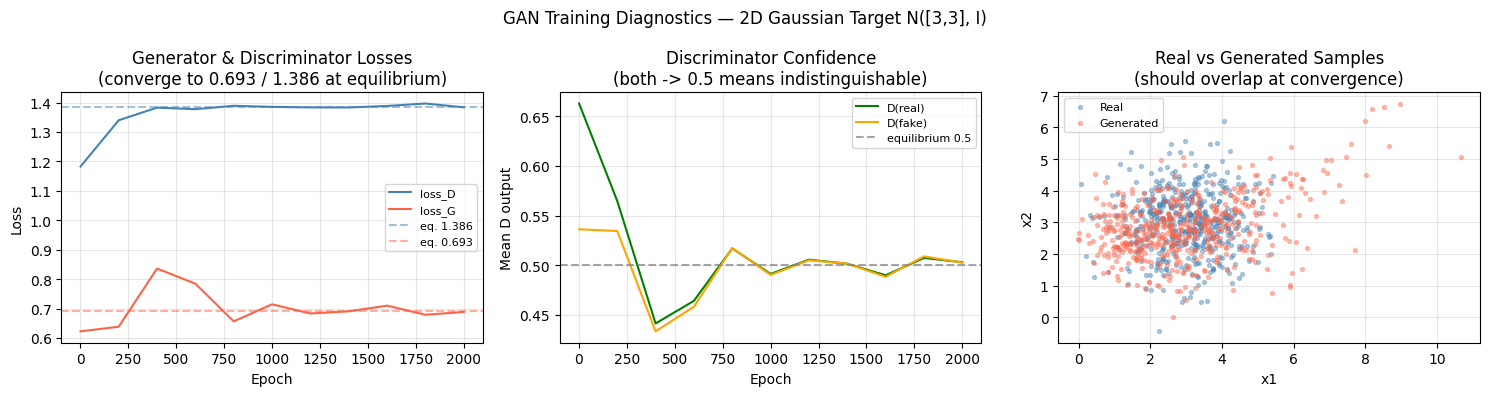

In [6]:
log_epochs = [1] + list(range(LOG_EVERY, EPOCHS + 1, LOG_EVERY))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("GAN Training Diagnostics — 2D Gaussian Target N([3,3], I)", fontsize=12)

# Panel 1: Losses
ax = axes[0]
ax.plot(log_epochs, history["loss_D"], label="loss_D", color="steelblue")
ax.plot(log_epochs, history["loss_G"], label="loss_G", color="tomato")
ax.axhline(1.386, ls="--", color="steelblue", alpha=0.5, label="eq. 1.386")
ax.axhline(0.693, ls="--", color="tomato",    alpha=0.5, label="eq. 0.693")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Generator & Discriminator Losses\n(converge to 0.693 / 1.386 at equilibrium)")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# Panel 2: Discriminator confidences
ax = axes[1]
ax.plot(log_epochs, history["D_real"], label="D(real)", color="green")
ax.plot(log_epochs, history["D_fake"], label="D(fake)", color="orange")
ax.axhline(0.5, ls="--", color="gray", alpha=0.7, label="equilibrium 0.5")
ax.set_xlabel("Epoch")
ax.set_ylabel("Mean D output")
ax.set_title("Discriminator Confidence\n(both -> 0.5 means indistinguishable)")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# Panel 3: Sample scatter — real vs generated
ax = axes[2]
with torch.no_grad():
    real_pts = sample_real(500).cpu().numpy()
    fake_pts = G(sample_noise(500)).cpu().numpy()
ax.scatter(real_pts[:, 0], real_pts[:, 1], s=8, alpha=0.4, label="Real", color="steelblue")
ax.scatter(fake_pts[:, 0], fake_pts[:, 1], s=8, alpha=0.4, label="Generated", color="tomato")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_title("Real vs Generated Samples\n(should overlap at convergence)")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("gan_diagnostics.png", dpi=120)
plt.show()